# Modelado utilizando Pyspark

In [1]:
import pandas as pd

# 2. Preparación y División de los Datos

In [2]:
from pyspark.sql import SparkSession
import os

# 1) SparkSession
spark = SparkSession.builder.appName("LendingClubRF").getOrCreate()

# 2) Ruta del parquet (ajústala si el nombre/carpeta cambia)
PATH = "leanding_cleaned.parquet"   # Ruta relativa

# (opcional) verificar que exista en disco
assert os.path.exists(PATH), f"No encontré el archivo: {PATH}"

# 3) Leer parquet
df = spark.read.parquet(PATH)

# 4) Chequeo rápido
df.printSchema()
df.show(5, truncate=False)
print("Filas:", df.count())


root
 |-- loan_amnt: double (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- fico_range_high: double (nullable = true)
 |-- emp_length: double (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- purpose: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- default: long (nullable = true)



+---------+--------+---------------+----------+----------+------------------+--------------+-----+----------+-------+
|loan_amnt|int_rate|fico_range_high|emp_length|annual_inc|purpose           |home_ownership|dti  |addr_state|default|
+---------+--------+---------------+----------+----------+------------------+--------------+-----+----------+-------+
|3600.0   |13.99   |679.0          |10.0      |55000.0   |debt_consolidation|MORTGAGE      |5.91 |PA        |0      |
|24700.0  |11.99   |719.0          |10.0      |65000.0   |small_business    |MORTGAGE      |16.06|SD        |0      |
|20000.0  |10.78   |699.0          |10.0      |63000.0   |home_improvement  |MORTGAGE      |10.78|IL        |0      |
|10400.0  |22.45   |699.0          |3.0       |104433.0  |major_purchase    |MORTGAGE      |25.37|PA        |0      |
|11950.0  |13.44   |694.0          |4.0       |34000.0   |debt_consolidation|RENT          |10.2 |GA        |0      |
+---------+--------+---------------+----------+---------

Filas: 1345310


## 2.1. Selección de Características

In [3]:
# Definimos las columnas que usaremos en el modelo
model_features = [
    "loan_amnt",
    "int_rate",
    "fico_range_high",
    "emp_length",
    "annual_inc",
    "purpose",
    "home_ownership",
    "dti",
    "addr_state"
]

# Variable objetivo
target_col = "default"

# DataFrame solo con features + target
df_model = df.select(model_features + [target_col])



##  2.2. División Estratificada de Datos (80/20)
Dividimos los datos en conjuntos de entrenamiento y prueba.

In [4]:
# Dividir en entrenamiento (80%) y prueba (20%)
train, test = df_model.randomSplit([0.8, 0.2], seed=42)

print("Tamaño entrenamiento:", train.count())
print("Tamaño prueba:", test.count())


Tamaño entrenamiento: 1076235


Tamaño prueba: 269075


##  2.3. Preprocesamiento de los datos

Se separaron las variables numéricas y categóricas, se imputaron los valores faltantes de las numéricas usando la mediana, y las categóricas fueron transformadas mediante indexación y codificación one-hot. 

Todas las variables procesadas se integraron en un único vector de características (features) con el fin de que los algoritmos de PySpark ML puedan utilizarlas directamente en el entrenamiento y la evaluación de los modelos. Para asegurar consistencia, estos pasos se encapsularon en un pipeline aplicado tanto al conjunto de entrenamiento como al de prueba.

In [5]:
from pyspark.sql.types import StringType, BooleanType, IntegerType, LongType, FloatType, DoubleType
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Imputer
from pyspark.ml import Pipeline

# --- columnas numéricas y categóricas (según tu df_model) ---
num_types = (IntegerType, LongType, FloatType, DoubleType)
num_cols = [f.name for f in df_model.schema.fields if isinstance(f.dataType, num_types) and f.name != "default"]
cat_cols = [c for c in df_model.columns if c not in num_cols + ["default"]]

# --- transformadores ---
imp_num = Imputer(strategy="median",
                  inputCols=num_cols,
                  outputCols=[c + "_imp" for c in num_cols])

idx_cols = [c + "_idx" for c in cat_cols]
ohe_cols = [c + "_ohe" for c in cat_cols]

indexer = StringIndexer(inputCols=cat_cols, outputCols=idx_cols, handleInvalid="keep")
encoder = OneHotEncoder(inputCols=idx_cols, outputCols=ohe_cols, dropLast=True)

feat_cols = [c + "_imp" for c in num_cols] + ohe_cols
assembler = VectorAssembler(inputCols=feat_cols, outputCol="features")

# --- pipeline SOLO de preprocesamiento ---
prep_pipe = Pipeline(stages=[imp_num, indexer, encoder, assembler])

# fit en TRAIN y transformar ambos
prep_model = prep_pipe.fit(train)
train_prep = prep_model.transform(train)
test_prep  = prep_model.transform(test)

# chequeo rápido
train_prep.select("features", "default").show(3, truncate=False)


+-----------------------------------------------------------------------------+-------+
|features                                                                     |default|
+-----------------------------------------------------------------------------+-------+
|(77,[0,1,2,3,4,5,9,20,28],[500.0,9.76,744.0,7.0,59000.0,22.17,1.0,1.0,1.0])  |0      |
|(77,[0,1,2,3,4,5,12,20,30],[500.0,10.46,694.0,3.0,26000.0,14.17,1.0,1.0,1.0])|0      |
|(77,[0,1,2,4,5,15,20,26],[500.0,10.71,684.0,7904.04,3.04,1.0,1.0,1.0])       |0      |
+-----------------------------------------------------------------------------+-------+
only showing top 3 rows


Aqui se puede observar las 3 primeras filas del vector features.

## 3.1. Entrenamiento del modelo y tiempo del modelo 

Para el entrenamiento de este modelo, es importante mencionar que se usaron los mejores hiperparametros encontrados en el modelado con scikit-learn.

Además, para abordar el problema de desbalance de clases, se asignaron pesos diferenciados en el entrenamiento, otorgando mayor relevancia a la clase minoritaria con el fin de mejorar el desempeño del modelo en su detección

In [6]:
from pyspark.sql.functions import when, col
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import time

# 1) Pesos
counts = {r['default']: r['count'] for r in train_prep.groupBy('default').count().collect()}
neg_n, pos_n = counts.get(0,1), counts.get(1,1)
ratio = neg_n / max(pos_n, 1)

train_w = train_prep.withColumn("weight",
                                when(col("default")==1, ratio).otherwise(1.0).cast("double"))
test_w  = test_prep.withColumn("weight",
                               when(col("default")==1, ratio).otherwise(1.0).cast("double"))

# 2) Modelo (usa los *_w!)
rf = RandomForestClassifier(
    labelCol="default", featuresCol="features",
    weightCol="weight",
    numTrees=50, maxDepth=12, maxBins=64,
    subsamplingRate=0.7, featureSubsetStrategy="sqrt",
    seed=42
)

t0 = time.time()
rf_model = rf.fit(train_w)                 # <<< aquí
t_train = time.time() - t0

t1 = time.time()
pred = rf_model.transform(test_w).cache()  # <<< y aquí
pred.count()
t_pred = time.time() - t1

# 3) Métricas
bin_eval = BinaryClassificationEvaluator(labelCol="default", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
multi_eval = MulticlassClassificationEvaluator(labelCol="default", predictionCol="prediction")

auc = bin_eval.evaluate(pred)
acc = multi_eval.evaluate(pred, {multi_eval.metricName: "accuracy"})
f1  = multi_eval.evaluate(pred, {multi_eval.metricName: "f1"})
prec= multi_eval.evaluate(pred, {multi_eval.metricName: "weightedPrecision"})
rec = multi_eval.evaluate(pred, {multi_eval.metricName: "weightedRecall"})

print(f"AUC: {auc:.4f} | Accuracy: {acc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
print(f"Tiempo entrenamiento: {t_train:.2f}s | Tiempo predicción: {t_pred:.2f}s")

pred.groupBy("default","prediction").count().orderBy("default","prediction").show()


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\site-packages\py4j\clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\socket.py", line 718, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [WinError 10054] Se ha forzado la interrupción de una conexión existente por el host remoto

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\site-packages\py4j\java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\sit

ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\site-packages\py4j\clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\socket.py", line 718, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [WinError 10054] Se ha forzado la interrupción de una conexión existente por el host remoto

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\site-packages\py4j\java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda

ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\site-packages\py4j\clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\socket.py", line 718, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [WinError 10054] Se ha forzado la interrupción de una conexión existente por el host remoto

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\site-packages\py4j\java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\OMAR DANIEL MEDINA V\anaconda

KeyboardInterrupt: 

## 3.2 Matriz de confusión y Curva-AUC

Para facilitar la interpretación de los resultados del modelo, se optó por graficar la matriz de confusión y la curva ROC-AUC utilizando Scikit-learn. Es importante destacar que esta librería se empleó únicamente como apoyo para la visualización e interpretación, las predicciones provinieron directamente de nuestro modelo desarrollado en PySpark .

Confusion matrix:
 [[130320  85237]
 [ 16943  36575]]
Confusion matrix (normalizada):
 [[0.60457327 0.39542673]
 [0.31658507 0.68341493]]


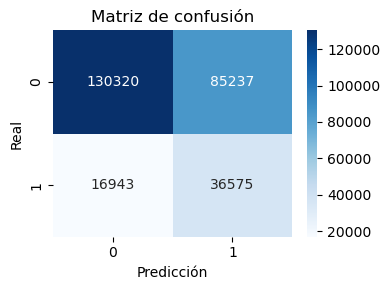

              precision    recall  f1-score   support

           0     0.8849    0.6046    0.7184    215557
           1     0.3003    0.6834    0.4172     53518

    accuracy                         0.6203    269075
   macro avg     0.5926    0.6440    0.5678    269075
weighted avg     0.7687    0.6203    0.6585    269075



In [8]:
# 1) Traer a pandas solo y_true e y_pred
pdf = (pred
       .select("default", "prediction")   # solo 2 cols
       .toPandas())

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = pdf["default"].astype(int)
y_pred = pdf["prediction"].astype(int)

# 2) Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

# 3) (Opcional) normalizada por filas
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
print("Confusion matrix (normalizada):\n", cm_norm)

# 4) Heatmap bonito
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues",
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

# 5) Reporte sklearn (precisión/recall/F1 por clase)
print(classification_report(y_true, y_pred, digits=4))


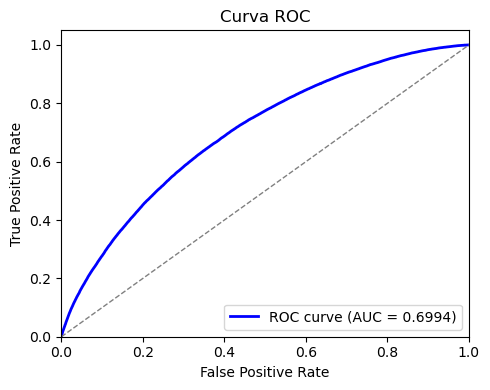

In [10]:
from sklearn.metrics import roc_curve, auc
# 1) Traer probas del modelo
pdf_proba = (pred
             .select("default", "probability")  # la col probas de PySpark
             .toPandas())

# Spark guarda "probability" como vector -> tomamos prob de la clase 1
pdf_proba["prob_1"] = pdf_proba["probability"].apply(lambda x: float(x[1]))

y_true = pdf_proba["default"].astype(int)
y_score = pdf_proba["prob_1"]

# 2) Calcular fpr, tpr y auc
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# 3) Graficar curva ROC
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Interpretación de resultados

## 1. Matriz de Confusión
Podemos observar que con la matriz de confusión el modelo muestra un mejor desempeño identificando la **clase 0**, mientras que en la **clase 1** se observa aun una confusión considerable, sin embargo cabe recalcar que para el desbalanceo de clases que existe en los datos el modelo logra captar una cantidad considerable de la clase minoritaria (verdaderos positivos).  

---

## 2. Métricas de Clasificación

El recall de la clase 1 es mayor que su precisión, lo que significa que el modelo tiende a detectar más casos positivos, aunque con un alto costo de falsos positivos. Esto resulta valioso en escenarios como este, donde es prioritario no dejar escapar a los positivos (personas que realmente no pagarán), incluso a costa de perder precisión. Además, es importante recordar que en contextos con un fuerte desbalance de clases, la métrica de accuracy puede ser engañosa, ya que se ve influenciada principalmente por la clase mayoritaria.

---

## 3. Curva ROC – AUC
- **AUC = 0.6994**, lo cual indica un desempeño **moderado**.  
- La curva ROC está por encima de la diagonal aleatoria, confirmando que el modelo es **mejor que el azar**, pero aún con margen de mejora.  

---

## Conclusión
El modelo tiene un **buen desempeño en la clase mayoritaria (0)** y logra capturar un porcentaje aceptable de la **clase minoritaria (1)**, aunque con baja precisión. Esto refleja la dificultad de clasificar correctamente los casos positivos en un contexto de **desbalance de clases**.  
 

